# CAS Exam 5: Chain Ladder Method (Development Method)

This notebook uses real data from:
- `.../chainladder-python/chainladder/utils/data/friedland_us_industry_auto.csv`

Learning goals:
- Work directly with the `chainladder.Triangle` structure.
- Show age-to-age factors, candidate LDF selections, tail alternatives, and selected CDFs.
- Project ultimates and implied IBNR with explicit actuarial considerations.


In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import chainladder as cl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from reservingengine.reserving import triangle_to_frame

DATA_PATH = ROOT / 'chainladder-python' / 'chainladder' / 'utils' / 'data' / 'friedland_us_industry_auto.csv'
raw = pd.read_csv(DATA_PATH)

raw.head()

,Accident Year,Calendar Year,Paid Claims,Reported Claims
0,1998,1998,18539254,37017487
1,1998,1999,33231039,43169009
2,1998,2000,40062008,45568919
3,1998,2001,43892039,46784558
4,1998,2002,45896535,47337318


*Initial Data Requirements*:
* Tabular data with:
    * one origin field (Accident Year)
    * one development (or valuation) field (Calendar Year)
    * one or more value columns (Paid Claims, Reported Claims)
* Data may be incremental or cumulative.
* Optional: one or more segment/index fields. (e.g. LOBs. Only auto data is used in this example)

## Step 1: Compile Data in `chainladder.Triangle` Form

The object below is the actual chainladder triangle structure used for all downstream calculations.    
*Structure*  
* 4D object: [index, columns, origin, development]  
    * index = segment keys (e.g., LOB, state, company); can be multi-level  
    * columns = measures (Paid, Incurred, Counts, Exposure, etc.)  
    * origin = accident/policy/report year (or period)  
    * development = development age (or valuation period)  


*Think of it as a labeled actuarial data cube with reserving semantics layered on top of pandas-like behavior.*


In [3]:
triangle = cl.Triangle(
    raw,
    origin='Accident Year',
    development='Calendar Year',
    columns=['Paid Claims', 'Reported Claims'],
    cumulative=True,
)
triangle

,Triangle Summary
Valuation:,2007-12
Grain:,OYDY
Shape:,"(1, 2, 10, 10)"
Index:,[Total]
Columns:,"[Paid Claims, Reported Claims]"


In [4]:
paid_triangle = triangle['Paid Claims']
reported_triangle = triangle['Reported Claims']
paid_triangle

,12,24,36,48,60,72,84,96,108,120
1998,"18,539,254","33,231,039","40,062,008","43,892,039","45,896,535","46,765,422","47,221,322","47,446,877","47,555,456","47,644,187"
1999,"20,410,193","36,090,684","43,259,402","47,159,241","49,208,532","50,162,043","50,625,757","50,878,808","51,000,534",
2000,"22,120,843","38,976,014","46,389,282","50,562,385","52,735,280","53,740,101","54,284,334","54,533,225",,
2001,"22,992,259","40,096,198","47,767,835","52,093,916","54,363,436","55,378,801","55,878,421",,,
2002,"24,092,782","41,795,313","49,903,803","54,352,884","56,754,376","57,807,215",,,,
2003,"24,084,451","41,399,612","49,070,332","53,584,201","55,930,654",,,,,
2004,"24,369,770","41,489,863","49,236,678","53,774,672",,,,,,
2005,"25,100,697","42,702,229","50,644,994",,,,,,,
2006,"25,608,776","43,606,497",,,,,,,,
2007,"27,229,969",,,,,,,,,


In [17]:
print("Origin:", paid_triangle.origin) # origin axis values
print("Development Ages:", paid_triangle.development.values) # development ages
print("Valuation Date:", paid_triangle.valuation_date) # latest valuation date of the triangle
print("Columns:", paid_triangle.columns) # measure names
print("Index:", paid_triangle.index) # segment keys. Default is Total
# index and slice triangles similar to pandas, but 4d
print("Shape:", paid_triangle.shape) # (index, values, number of origin periods, number of development ages)
print("Is Cumulative:", paid_triangle.is_cumulative) # indicates cumulative vs incremental

Origin: PeriodIndex(['1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
             '2006', '2007'],
            dtype='period[Y-DEC]', name='origin')
Development Ages: [ 12  24  36  48  60  72  84  96 108 120]
Valuation Date: 2007-12-31 23:59:59.999999999
Columns: Index(['Paid Claims'], dtype='object', name='columns')
Index:    Total
0  Total
Shape: (1, 1, 10, 10)
Is Cumulative: True


In [18]:
print("Latest Diagonal:") 
print(paid_triangle.latest_diagonal) # most recent observed values

Latest Diagonal:
            2007
1998  47644187.0
1999  51000534.0
2000  54533225.0
2001  55878421.0
2002  57807215.0
2003  55930654.0
2004  53774672.0
2005  50644994.0
2006  43606497.0
2007  27229969.0


In [19]:
print("Paid Losses for every maturity of first 3 origin periods :\n", paid_triangle.values[0, 0, :3, :]) # underlying numpy array 

Paid Losses for every maturity of first 3 origin periods :
 [[18539254. 33231039. 40062008. 43892039. 45896535. 46765422. 47221322.
  47446877. 47555456. 47644187.]
 [20410193. 36090684. 43259402. 47159241. 49208532. 50162043. 50625757.
  50878808. 51000534.       nan]
 [22120843. 38976014. 46389282. 50562385. 52735280. 53740101. 54284334.
  54533225.       nan       nan]]


<Axes: >

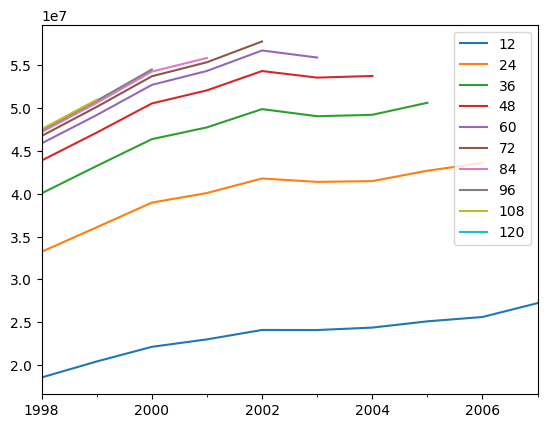

In [20]:
paid_triangle.plot()

In [24]:
paid_triangle

,12,24,36,48,60,72,84,96,108,120
1998,"18,539,254","33,231,039","40,062,008","43,892,039","45,896,535","46,765,422","47,221,322","47,446,877","47,555,456","47,644,187"
1999,"20,410,193","36,090,684","43,259,402","47,159,241","49,208,532","50,162,043","50,625,757","50,878,808","51,000,534",
2000,"22,120,843","38,976,014","46,389,282","50,562,385","52,735,280","53,740,101","54,284,334","54,533,225",,
2001,"22,992,259","40,096,198","47,767,835","52,093,916","54,363,436","55,378,801","55,878,421",,,
2002,"24,092,782","41,795,313","49,903,803","54,352,884","56,754,376","57,807,215",,,,
2003,"24,084,451","41,399,612","49,070,332","53,584,201","55,930,654",,,,,
2004,"24,369,770","41,489,863","49,236,678","53,774,672",,,,,,
2005,"25,100,697","42,702,229","50,644,994",,,,,,,
2006,"25,608,776","43,606,497",,,,,,,,
2007,"27,229,969",,,,,,,,,


In [21]:
paid_triangle.dev_to_val()

,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007
1998,"18,539,254","33,231,039","40,062,008","43,892,039","45,896,535","46,765,422","47,221,322","47,446,877","47,555,456","47,644,187"
1999,,"20,410,193","36,090,684","43,259,402","47,159,241","49,208,532","50,162,043","50,625,757","50,878,808","51,000,534"
2000,,,"22,120,843","38,976,014","46,389,282","50,562,385","52,735,280","53,740,101","54,284,334","54,533,225"
2001,,,,"22,992,259","40,096,198","47,767,835","52,093,916","54,363,436","55,378,801","55,878,421"
2002,,,,,"24,092,782","41,795,313","49,903,803","54,352,884","56,754,376","57,807,215"
2003,,,,,,"24,084,451","41,399,612","49,070,332","53,584,201","55,930,654"
2004,,,,,,,"24,369,770","41,489,863","49,236,678","53,774,672"
2005,,,,,,,,"25,100,697","42,702,229","50,644,994"
2006,,,,,,,,,"25,608,776","43,606,497"
2007,,,,,,,,,,"27,229,969"


In [23]:
paid_triangle.cum_to_incr()

,12,24,36,48,60,72,84,96,108,120
1998,"18,539,254","14,691,785","6,830,969","3,830,031","2,004,496","868,887","455,900","225,555","108,579","88,731"
1999,"20,410,193","15,680,491","7,168,718","3,899,839","2,049,291","953,511","463,714","253,051","121,726",
2000,"22,120,843","16,855,171","7,413,268","4,173,103","2,172,895","1,004,821","544,233","248,891",,
2001,"22,992,259","17,103,939","7,671,637","4,326,081","2,269,520","1,015,365","499,620",,,
2002,"24,092,782","17,702,531","8,108,490","4,449,081","2,401,492","1,052,839",,,,
2003,"24,084,451","17,315,161","7,670,720","4,513,869","2,346,453",,,,,
2004,"24,369,770","17,120,093","7,746,815","4,537,994",,,,,,
2005,"25,100,697","17,601,532","7,942,765",,,,,,,
2006,"25,608,776","17,997,721",,,,,,,,
2007,"27,229,969",,,,,,,,,


## Step 2: Age-to-Age Factors and Pattern Diagnostics

We inspect link ratios by AY. Educationally, this is where we look for trend, volatility, and possible structural shifts.
If early-age factors are drifting down or up over time, that influences selection of recent vs all-year averages.


In [36]:
age_to_age = paid_triangle.link_ratio
age_to_age.heatmap()


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108,108-120
1998,1.7925,1.2056,1.0956,1.0457,1.0189,1.0097,1.0048,1.0023,1.0019
1999,1.7683,1.1986,1.0902,1.0435,1.0194,1.0092,1.0050,1.0024,
2000,1.7620,1.1902,1.0900,1.0430,1.0191,1.0101,1.0046,,
2001,1.7439,1.1913,1.0906,1.0436,1.0187,1.0090,,,
2002,1.7348,1.1940,1.0892,1.0442,1.0186,,,,
2003,1.7189,1.1853,1.0920,1.0438,,,,,
2004,1.7025,1.1867,1.0922,,,,,,
2005,1.7012,1.1860,,,,,,,
2006,1.7028,,,,,,,,


Here is a clean, exam-ready markdown commentary you can paste directly into your notebook.

---

### Commentary on the 12–24 Age-to-Age Factors (Accident Years 1998–2006)

The 12–24 development factors show a **general downward trend across accident years**, with relatively small year-to-year fluctuations.

#### 1. Observed Pattern

* Earlier accident years (e.g., 1998–1999) exhibit higher 12–24 factors.
* More recent accident years show gradually smaller factors.
* The year-over-year change is modest and mostly negative.
* There are no extreme spikes or volatility.

This indicates a **smooth declining pattern** rather than random instability.

---

### 2. Interpretation of a Decreasing 12–24 Factor

The 12–24 factor reflects the amount of development occurring between the first and second year after accident.

A decreasing factor over time may suggest:

* **Faster claim reporting or settlement** in more recent years.
* Improved claims handling or operational efficiency.
* Shifts in case reserving philosophy.
* A reduction in late-reported claims.
* Structural changes in mix of business.

The key actuarial question is:

> Is this trend structural (permanent change) or random fluctuation?

---

### 3. Relevance for Development Method Assumptions

The Chain Ladder method assumes:

* Development patterns are stable over time.
* Future development will resemble historical development.

A consistent downward drift may indicate:

* Violation of strict stationarity.
* A possible calendar year or operational effect.
* A change in reporting speed.

This does **not automatically invalidate Chain Ladder**, but it requires judgment.

---

### 4. Factor Selection Considerations (Exam Perspective)

When selecting the 12–24 factor, several approaches may be considered:

#### Option A: Volume-Weighted Average

* Appropriate if trend is modest and data is credible.
* Smooths minor fluctuations.
* Most commonly used default.

#### Option B: Simple or Recent Average

* May be appropriate if operational changes suggest older years are not representative.
* More weight on recent accident years.

#### Option C: Exclude Early Accident Years

* If earlier high factors are believed to reflect outdated claims practices.
* Common exam scenario: "process change occurred in year X."

#### Option D: Trend Adjustment

* If a structural acceleration in reporting is believed permanent,
  projecting a slightly lower factor may be justified.

---

### 5. Stability and Credibility Assessment

Indicators supporting use of traditional Chain Ladder:

* Smooth progression.
* No extreme volatility.
* Changes are gradual rather than abrupt.
* No obvious outliers.

Indicators suggesting caution:

* Systematic monotonic decline.
* Known operational change during period.
* Evidence of valuation correlation.

---

### 6. Potential Exam Questions Based on This Pattern

If presented with this table, typical questions might include:

* Is the 12–24 factor stable?
* Should earlier accident years be excluded?
* Is there evidence of a change in settlement speed?
* How would faster reporting affect ultimates?
* Would the development method overstate or understate ultimates if the trend continues?
* How would this impact Bornhuetter–Ferguson?
* Would valuation correlation likely detect this?

---

### 7. Impact on Ultimate Estimates

If more recent years truly develop less between 12–24:

* Using older higher factors may **overstate ultimates**.
* Using only recent lower factors may reduce projected development.
* Choice of selected factor materially affects immature accident years.

Since 12–24 is an early maturity period, its selection significantly impacts:

* Young accident years
* IBNR estimates
* Sensitivity of ultimates

In [31]:
first_factor = age_to_age.to_frame()['12-24'].dropna().to_frame(name='12-24')
first_factor['ChangeFromPriorAY'] = first_factor['12-24'].diff()
first_factor

,12-24,ChangeFromPriorAY
1998,1.792469,NaN
1999,1.768268,-0.024201
2000,1.761959,-0.006309
2001,1.743900,-0.018059
2002,1.734765,-0.009135
2003,1.718935,-0.015830
2004,1.702514,-0.016422
2005,1.701237,-0.001277
2006,1.702795,0.001558


This uses chainladder's Mack-style diagnostics (not exam-5):  
- `DevelopmentCorrelation` for serial/development-period correlation.
    * H_0: Independence between successive development factors (rejected)
- `ValuationCorrelation` for calendar-year/valuation effects.  

In [41]:
development_corr = cl.DevelopmentCorrelation(paid_triangle, p_critical=0.5)
valuation_corr = cl.ValuationCorrelation(paid_triangle, p_critical=0.1, total=True)

valuation_z = float(valuation_corr.z.iloc[0, 0]) if hasattr(valuation_corr.z, "iloc") else float(valuation_corr.z)
valuation_flag = bool(valuation_corr.z_critical.iloc[0, 0]) if hasattr(valuation_corr.z_critical, "iloc") else bool(valuation_corr.z_critical)

correlation_summary = pd.DataFrame(
    [
        {
            'DevelopmentCorrReject': bool(development_corr.reject),
            'Development_p_critical': development_corr.p_critical,
            'ValuationZ': valuation_z,
            'ValuationCorrFlag': valuation_flag,
            'Valuation_p_critical': valuation_corr.p_critical,
        }
    ]
)

correlation_summary


,DevelopmentCorrReject,Development_p_critical,ValuationZ,ValuationCorrFlag,Valuation_p_critical
0,True,0.5,13.0,False,0.1


Development Correlation Test: Reject the null
*Translation:*
* Adjacent development periods are correlated.  
* The Mack independence assumption is violated.  
* Development factors are not independent across columns.  

This affects:  
* Mack standard error estimates  
* Variance calculations  
* Confidence intervals   
* *It does not automatically invalidate point estimates, but it weakens the statistical assumptions behind the model.*  

Why this matters  
* If development factors are correlated: 
    * Variance estimates are understated.  
    * The triangle may have structural effects.  
*You should be cautious interpreting Mack results.*

The valuation correlation test does not indicate significant calendar-year effects, suggesting the core Chain Ladder assumption that development depends only on age is not materially violated.

## Steps 3-4: Candidate LDF Sets and Selected Pattern

Candidate sets shown below:
- `simple_all_periods`
- `volume_all_periods`
- `regression_all_periods`
- `volume_recent_5`

Selection used here for teaching: recent-5 volume for the first two intervals (where trend pressure is highest), then all-year volume for later intervals (where credibility is lower and stability matters).   


Note: for chainladder-python (as with sklearn), .fit() stores the parrameters & attributes (.ultimate_, .ibnr_, .latest_diagonal) expose results


In [63]:
candidate_specs = {
    'simple_all_periods': {'average': 'simple', 'n_periods': -1},
    'volume_all_periods': {'average': 'volume', 'n_periods': -1},
    'regression_all_periods': {'average': 'regression', 'n_periods': -1},
    'volume_recent_5': {'average': 'volume', 'n_periods': 5},
}

candidate_models = {name: cl.Development(**spec).fit(paid_triangle) for name, spec in candidate_specs.items()}
ldf_comparison = pd.DataFrame({name: model.ldf_.to_frame().iloc[0] for name, model in candidate_models.items()}).T

selected_average = ['volume'] * ldf_comparison.shape[1]
selected_n_periods = [5, 5] + [-1] * (ldf_comparison.shape[1] - 2)
selected_dev_model = cl.Development(average=selected_average, n_periods=selected_n_periods).fit(paid_triangle)
selected_ldf = selected_dev_model.ldf_.to_frame().iloc[0]

ldf_comparison.loc['selected_hybrid'] = selected_ldf
ldf_comparison


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108,108-120
simple_all_periods,1.736316,1.192216,1.091369,1.043940,1.018918,1.009535,1.004787,1.002340,1.001866
volume_all_periods,1.733500,1.191758,1.091283,1.043906,1.018904,1.009529,1.004782,1.002342,1.001866
regression_all_periods,1.730925,1.191343,1.091208,1.043878,1.018890,1.009523,1.004777,1.002344,1.001866
volume_recent_5,1.711825,1.188644,1.090772,1.043606,1.018904,1.009529,1.004782,1.002342,1.001866
selected_hybrid,1.711825,1.188644,1.091283,1.043906,1.018904,1.009529,1.004782,1.002342,1.001866


Volume-weighted averages were selected due to their credibility and stability. Early maturities show modest downward drift in recent years; therefore, recent-year experience was emphasized for immature ages. Later maturities are stable across methods, so all-period volume-weighted averages were deemed appropriate. The selected factors produce a smooth progression and reflect both historical credibility and recent experience.

## Step 5: Tail Factor Choices

Three practical tail views demonstrated:
- Industry benchmark constant tail (1.010).
- Data-fitted `TailCurve` from the selected developed triangle.
- Paid-vs-reported proxy using mature AY latest reported/paid relationship.

No single tail is universally correct; appropriateness depends on line behavior, maturity, and external benchmark support.


In [58]:
selected_dev_triangle = selected_dev_model.transform(paid_triangle)
tail_curve_model = cl.TailCurve().fit(selected_dev_triangle) # extrapolate development beyond final maturity
tail_curve_factor = float(tail_curve_model.tail_.iloc[0, 0]) # extract tail factor from model

In [61]:
tail_curve_factor

1.0011056328627517

In [60]:
tail_curve_model

,curve,'exponential'
,fit_period,"(None, ...)"
,extrap_periods,100
,errors,'ignore'
,attachment_age,None
,reg_threshold,"(1.00001, ...)"
,projection_period,12


In [ ]:


#set up matrices for reported vs paid ratio analysis at mature ages
paid_long = triangle_to_frame(paid_triangle, origin_as_datetime=False).reset_index()
reported_long = triangle_to_frame(reported_triangle, origin_as_datetime=False).reset_index()
paid_matrix = paid_long.pivot(index='origin', columns='development', values='Paid Claims').sort_index().sort_index(axis=1)
reported_matrix = reported_long.pivot(index='origin', columns='development', values='Reported Claims').sort_index().sort_index(axis=1)

latest_age = paid_matrix.notna().iloc[:, ::-1].idxmax(axis=1)
mature_mask = latest_age >= 96

# get reported/paid ratio at mature ages 
mature_ratio = (reported_matrix.max(axis=1) / paid_matrix.max(axis=1)).where(mature_mask)
reported_paid_proxy_tail = float(mature_ratio.mean())

tail_candidates = pd.DataFrame(
    {
        'TailFactor': {
            'NoTail_1.000': 1.000,
            'IndustryBenchmark_example': 1.010,
            'TailCurve_FromData': tail_curve_factor,
            'MatureReportedPaidProxy': reported_paid_proxy_tail,
        },
        'Consideration': {
            'NoTail_1.000': 'Only reasonable if practically fully developed by 120 months.',
            'IndustryBenchmark_example': 'External benchmark; useful when data is sparse or noisy.',
            'TailCurve_FromData': 'Data-driven fit; sensitive when tail history is sparse.',
            'MatureReportedPaidProxy': 'Good if paid-vs-reported have stable relationship at mature ages.',
        },
    }
)
tail_candidates


,TailFactor,Consideration
NoTail_1.000,1.000000,Only reasonable if practically fully developed...
IndustryBenchmark_example,1.010000,External benchmark; useful when data is sparse...
TailCurve_FromData,1.001106,Data-driven fit; sensitive when tail history i...
MatureReportedPaidProxy,1.003760,Good if paid-vs-reported have stable relations...


## Steps 6-7: Selected CDFs, Ultimate, and IBNR

First, compare total ultimate/IBNR sensitivity across tail choices.
Then select one tail assumption for the final AY-level projection table.


In [48]:
sensitivity_rows = []
for label, row in tail_candidates.iterrows():
    tail_factor = float(row['TailFactor'])
    tailed = cl.TailConstant(tail=tail_factor).fit_transform(selected_dev_triangle)
    model = cl.Chainladder().fit(tailed)
    sensitivity_rows.append(
        {
            'TailOption': label,
            'TailFactorUsed': tail_factor,
            'TotalLatest': float(tailed.latest_diagonal.sum()),
            'TotalUltimate': float(model.ultimate_.sum()),
            'TotalIBNR': float(model.ibnr_.sum()),
        }
    )

tail_sensitivity = pd.DataFrame(sensitivity_rows).set_index('TailOption').sort_values('TotalUltimate')

tail_sensitivity


,TailFactorUsed,TotalLatest,TotalUltimate,TotalIBNR
TailOption,,,,
NoTail_1.000,1.000000,498050368.0,5.717564e+08,7.370600e+07
TailCurve_FromData,1.001106,498050368.0,5.723885e+08,7.433815e+07
MatureReportedPaidProxy,1.003760,498050368.0,5.739060e+08,7.585558e+07
IndustryBenchmark_example,1.010000,498050368.0,5.774739e+08,7.942356e+07


In [57]:
selected_tail_label = 'IndustryBenchmark_example' # choose based on considerations and sensitivity results
selected_tail_factor = float(tail_candidates.loc[selected_tail_label, 'TailFactor'])

selected_tail_model = cl.TailConstant(tail=selected_tail_factor).fit(selected_dev_triangle)
selected_tail_model

,tail,1.01
,decay,0.5
,attachment_age,None
,projection_period,12


In [56]:
selected_tail_model.cdf_

,12-Ult,24-Ult,36-Ult,48-Ult,60-Ult,72-Ult,84-Ult,96-Ult,108-Ult,120-Ult,132-Ult
(All),2.4299,1.4195,1.1942,1.0943,1.0483,1.0288,1.0191,1.0143,1.0119,1.0100,1.0050


**Justification:**  
* Late-age development data may be sparse and less credible.  
* External benchmarks provide stability when internal late emergence is limited.  
* The selected benchmark is consistent with plausible long-tail behavior.  
* Sensitivity analysis shows the impact is reasonable and not extreme.  

***Alternative justifications*** (if needed):  
* If late data were stable and credible, TailCurve could be defended.
* If business appeared fully developed, No Tail could be justified.
* If reported/paid maturity relationship is stable, proxy approach may be preferred.

## Final Projection and Actuarial Interpretation

Key assumptions (development method):
1. Future development follows patterns reasonably consistent with observed history.
2. Immature AY observed claims contain information about unobserved emergence.
3. Processes, mix, and program terms are stable enough for pattern transferability.

Method tends to work best with credible historical volume and relatively stable reporting/settlement behavior.


In [65]:
selected_tailed_triangle = selected_tail_model.transform(selected_dev_triangle)
selected_model = cl.Chainladder().fit(selected_tailed_triangle)
selected_model

Chainladder()

In [69]:
latest = selected_tailed_triangle.latest_diagonal.to_frame().copy()
latest.columns = ['Latest']
ultimate = selected_model.ultimate_.to_frame().copy()
ultimate.columns = ['Ultimate']
ibnr = selected_model.ibnr_.to_frame().copy()
ibnr.columns = ['IBNR']

ay_projection = latest.join(ultimate).join(ibnr)
ay_projection.index = ay_projection.index.year
ay_projection.index.name = 'AccidentYear'
ay_projection.loc['Total'] = ay_projection.sum()
ay_projection

,Latest,Ultimate,IBNR
AccidentYear,,,
1998,47644187.0,4.812063e+07,4.764419e+05
1999,51000534.0,5.160665e+07,6.061159e+05
2000,54533225.0,5.531057e+07,7.773496e+05
2001,55878421.0,5.694597e+07,1.067546e+06
2002,57807215.0,5.947299e+07,1.665779e+06
2003,55930654.0,5.863016e+07,2.699502e+06
2004,53774672.0,5.884513e+07,5.070454e+06
2005,50644994.0,6.047930e+07,9.834307e+06
2006,43606497.0,6.189751e+07,1.829101e+07


In [70]:
impact_table = pd.DataFrame(
    [
        ['Increase in exposure', 'Claims increase; factors broadly unchanged if average accident date is unchanged', 'Claims increase; factors broadly unchanged if average accident date is unchanged'],
        ['Average accident date shifts forward', 'Development factors and ultimates tend to be understated', 'Development factors and ultimates tend to be understated'],
        ['Increase claim ratios', 'Claims increase, development factors often less affected', 'Claims increase, development factors often less affected'],
        ['Speedup in settlement rate', 'Can overstate paid-based development and ultimate', 'Often limited direct effect'],
        ['Increase in case outstanding adequacy', 'Often limited direct effect', 'Can overstate reported-based development and ultimate'],
        ['Change in product mix', 'Patterns and selected factors should be re-segmented/reselected', 'Patterns and selected factors should be re-segmented/reselected'],
    ],
    columns=['Description', 'Paid impact', 'Reported impact'],
)
impact_table


,Description,Paid impact,Reported impact
0,Increase in exposure,Claims increase; factors broadly unchanged if ...,Claims increase; factors broadly unchanged if ...
1,Average accident date shifts forward,Development factors and ultimates tend to be u...,Development factors and ultimates tend to be u...
2,Increase claim ratios,"Claims increase, development factors often les...","Claims increase, development factors often les..."
3,Speedup in settlement rate,Can overstate paid-based development and ultimate,Often limited direct effect
4,Increase in case outstanding adequacy,Often limited direct effect,Can overstate reported-based development and u...
5,Change in product mix,Patterns and selected factors should be re-seg...,Patterns and selected factors should be re-seg...
